<a href="https://colab.research.google.com/github/eugeniatate-duke/XAI-assumption-junction/blob/main/assumption_junction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telco Customer Churn Interpretability using LinReg, LogReg, GAMs

A telecommunications company is interested in understanding the factors that contribute to customer churn (customers leaving the company for a competitor) and developing interpretable models to predict which customers are at risk of churning.

The purpose of this notebook is to help the company analyze the data.

**Importing Libraries and Loading Dataset**

https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data

In [185]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


url = "https://raw.githubusercontent.com/eugeniatate-duke/XAI-assumption-junction/main/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(url)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Exploratory Data Analysis
Purpose: check whether assumptions about linear, logistic, and GAM models are met and identify factors associated with churn.


In [186]:
print("Shape:", df.shape)
df.info()
display(df.describe(include="all").T)

Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Data Manipulation**

I noticed TotalCharges is not numeric and should be converted to numeric. Churn also should be 0 for No and 1 for Yes.


In [187]:
# Convert TotalCharges to numeric.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Convert the target to binary.
df["ChurnBinary"] = df["Churn"].map({"No": 0, "Yes": 1})

print("Missing values:")
print(df.isna().sum().sort_values(ascending=False).head())

Missing values:
TotalCharges     11
customerID        0
SeniorCitizen     0
Partner           0
Dependents        0
dtype: int64


In [188]:
df[np.isnan(df['TotalCharges'])]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnBinary
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,0
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No,0
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No,0
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No,0
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No,0
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No,0
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No,0
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No,0
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No,0
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No,0


Since 11 customers are likely very new and have not incurred charges yet, we want to fill the values with zero. Also, customerID field seems unnecessary as it is not adding value, so it is removed.

In [189]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print(df.isna().sum().sum(), "missing values remain")

0 missing values remain


In [190]:
# remove customerID column as it is not adding any value
df = df.drop("customerID", axis=1)

## Feature Grouping

In [191]:
feature_groups = {
    "Demographic": [
        "gender",
        "SeniorCitizen",
        "Partner",
        "Dependents"
    ],

    "Service": [
        "PhoneService",
        "MultipleLines",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies"
    ],

    "Account": [
        "tenure",
        "Contract",
        "PaperlessBilling",
        "PaymentMethod"
    ],

    "Billing": [
        "MonthlyCharges",
        "TotalCharges"
    ]
}

numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

gam_smooth_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

# Churn Distribution

In [192]:
churn_counts = df["Churn"].value_counts()
print(churn_counts)
print("\nProportions:")
print(df["Churn"].value_counts(normalize=True).round(3))

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proportions:
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


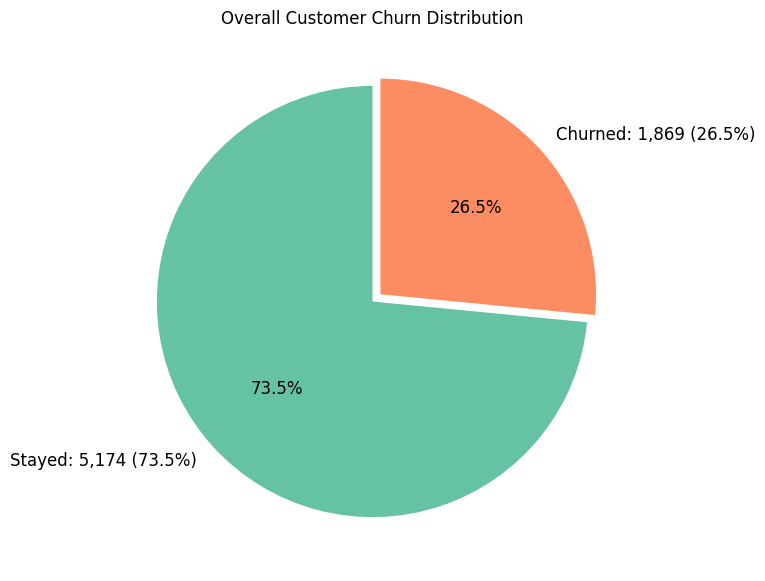

In [193]:
labels = [
    f"Stayed: {churn_counts['No']:,} ({churn_counts['No'] / len(df):.1%})",
    f"Churned: {churn_counts['Yes']:,} ({churn_counts['Yes'] / len(df):.1%})"
]

plt.figure(figsize=(7, 7))

plt.pie(
    churn_counts[["No", "Yes"]],
    labels=labels,
    colors=["#66c2a5", "#fc8d62"],
    autopct="%1.1f%%",
    startangle=90,
    explode=(0, 0.05),
    textprops={"fontsize": 12}
)

plt.title("Overall Customer Churn Distribution")
plt.show()

73.5% of customers stayed with the company, while 26.5% churned.
The target is imbalanced, and accuracy by itself is not to be used
to evaluate the models.

## Numeric Distributions

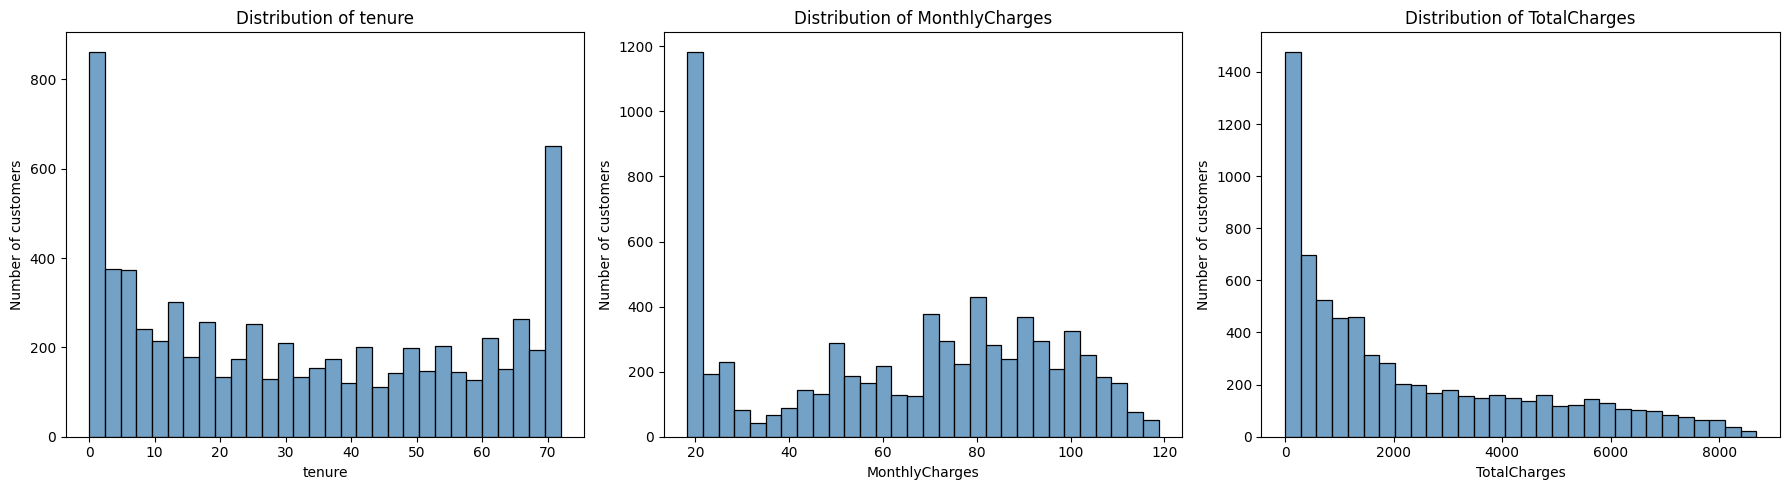

In [194]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, numeric_features):
    sns.histplot(
        data=df,
        x=feature,
        bins=30,
        color="steelblue",
        ax=ax
    )

    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of customers")

plt.tight_layout()
plt.show()

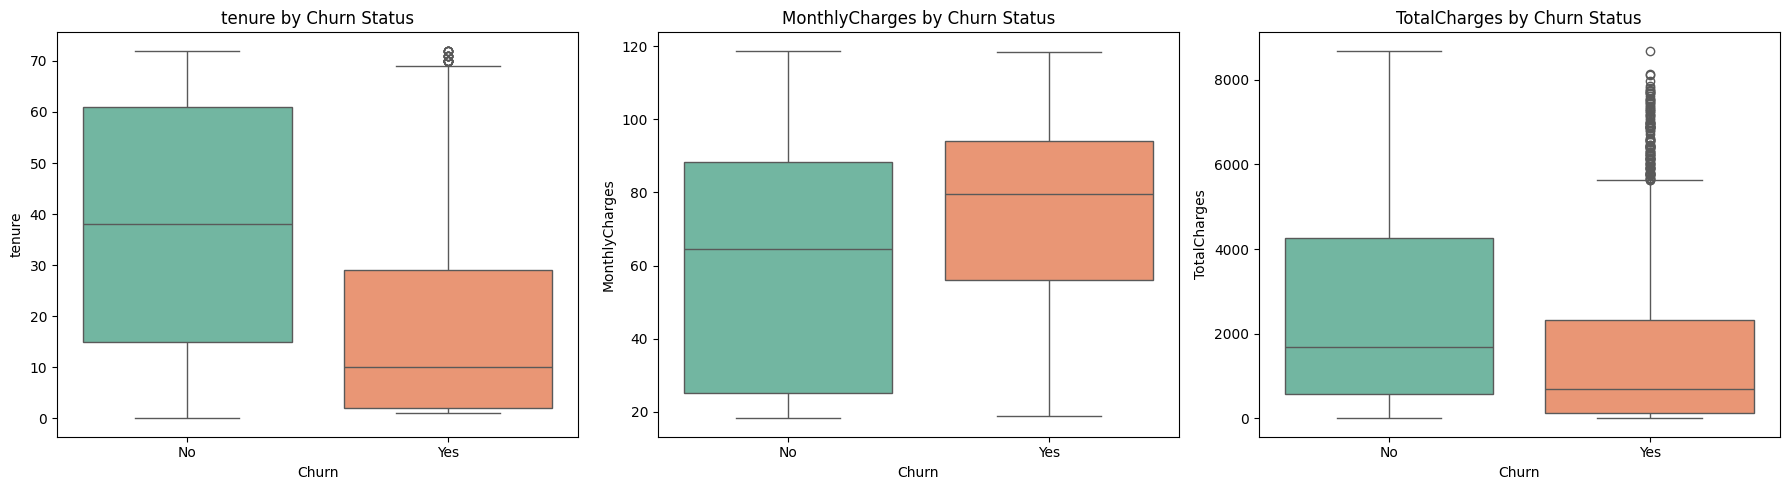

In [195]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, numeric_features):
    sns.boxplot(
        data=df,
        x="Churn",
        y=feature,
        hue="Churn",
        palette={
            "No": "#66c2a5",
            "Yes": "#fc8d62"
        },
        legend=False,
        ax=ax
    )

    ax.set_title(f"{feature} by Churn Status")
    ax.set_xlabel("Churn")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()


*   Customers who churn tend to have shorter tenure than customers who stay.
*   Churned customers generally have higher monthly charges, although the relationship is not
perfectly linear across all charge levels.
*   Churned customers tend to have lower total charges, which is partly explained by their
shorter tenure. TotalCharges should therefore be interpreted together with tenure.





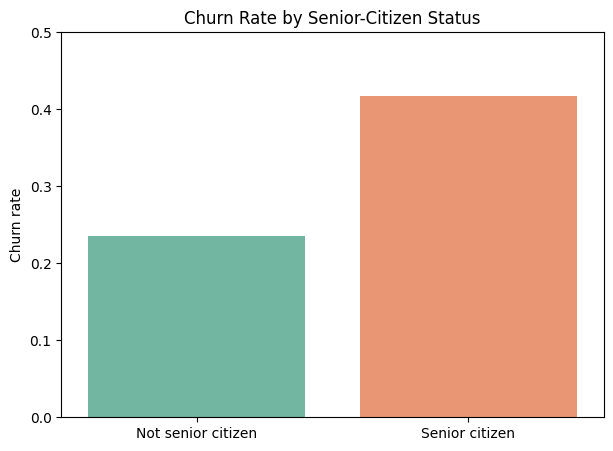

In [196]:
senior_churn = (
    df.groupby("SeniorCitizen")["ChurnBinary"]
    .mean()
    .reset_index()
)

senior_churn["SeniorCitizen"] = senior_churn["SeniorCitizen"].map({
    0: "Not senior citizen",
    1: "Senior citizen"
})

plt.figure(figsize=(7, 5))

sns.barplot(
    data=senior_churn,
    x="SeniorCitizen",
    y="ChurnBinary",
    hue="SeniorCitizen",
    palette=["#66c2a5", "#fc8d62"],
    legend=False
)

plt.title("Churn Rate by Senior-Citizen Status")
plt.xlabel("")
plt.ylabel("Churn rate")
plt.ylim(0, 0.5)

plt.show()

The observed churn rate is higher for senior citizens than for non-senior citizens. This
is an association in the dataset and does not show that senior-citizen status causes
churn.

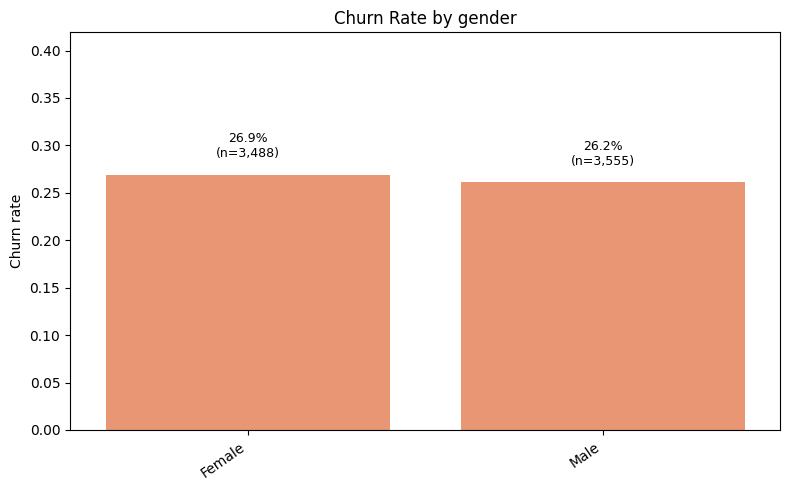

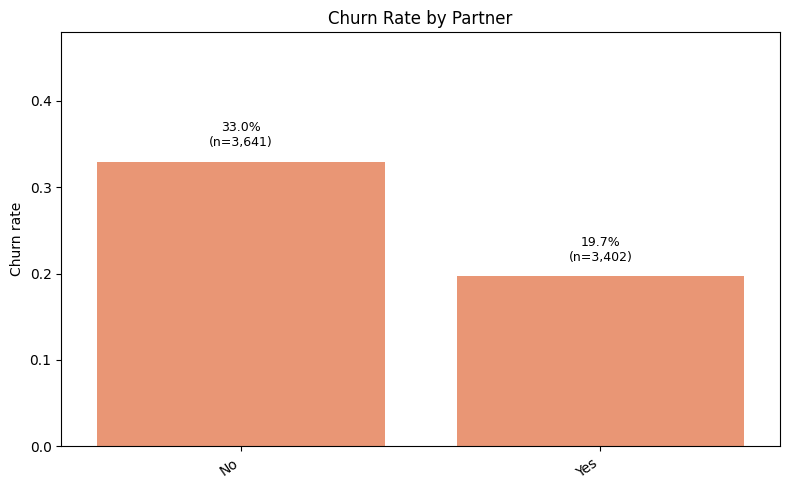

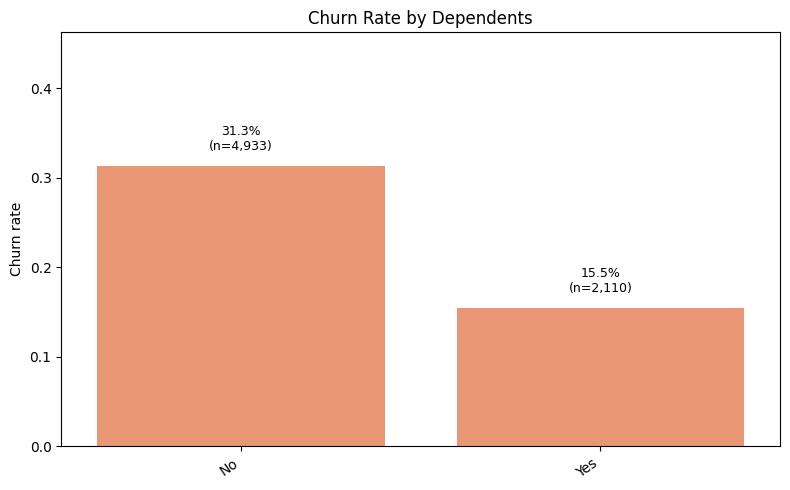

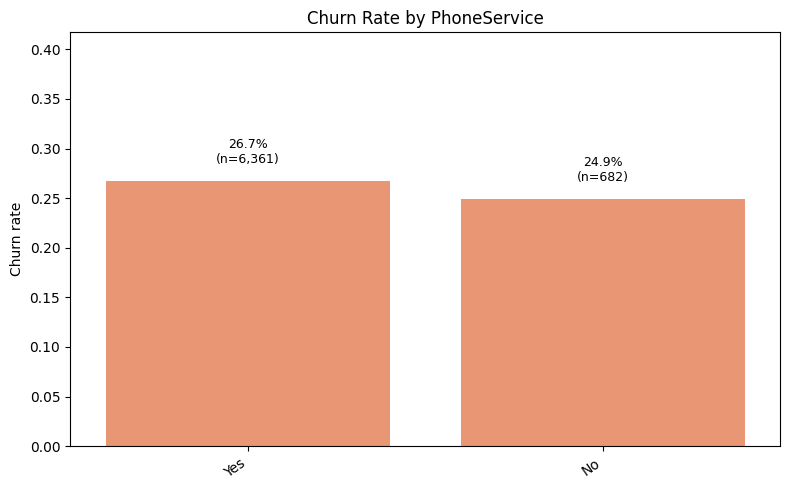

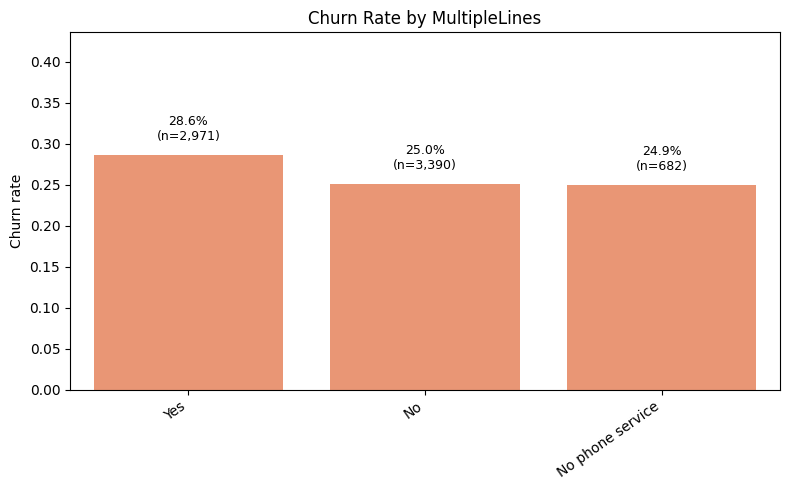

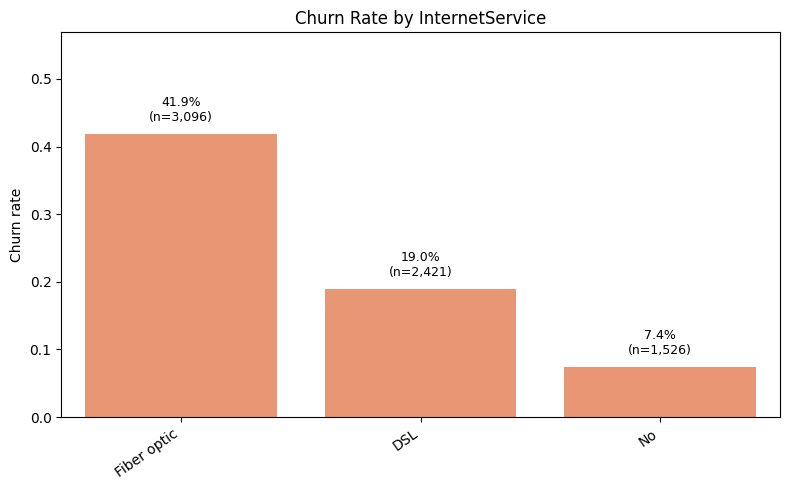

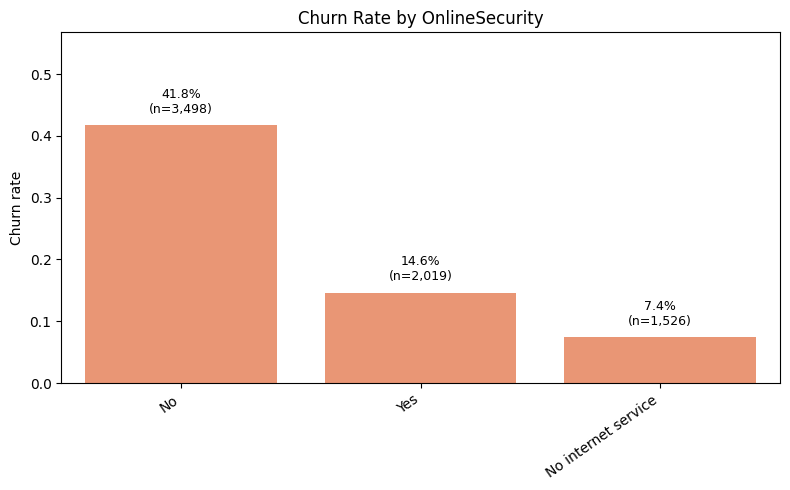

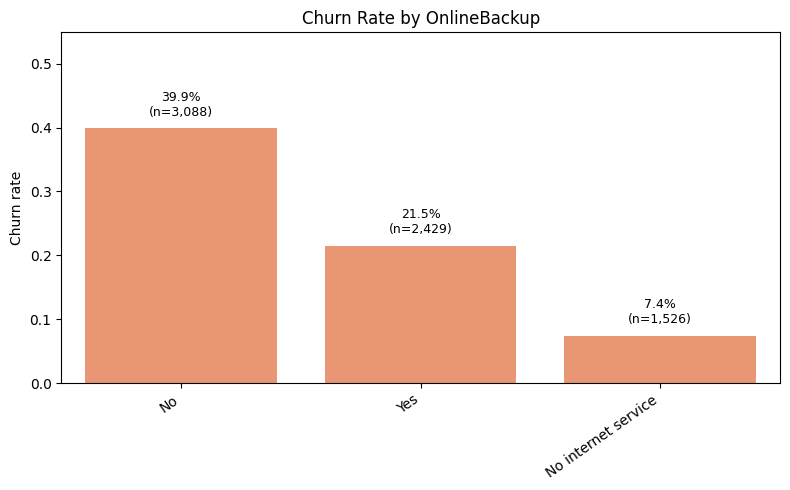

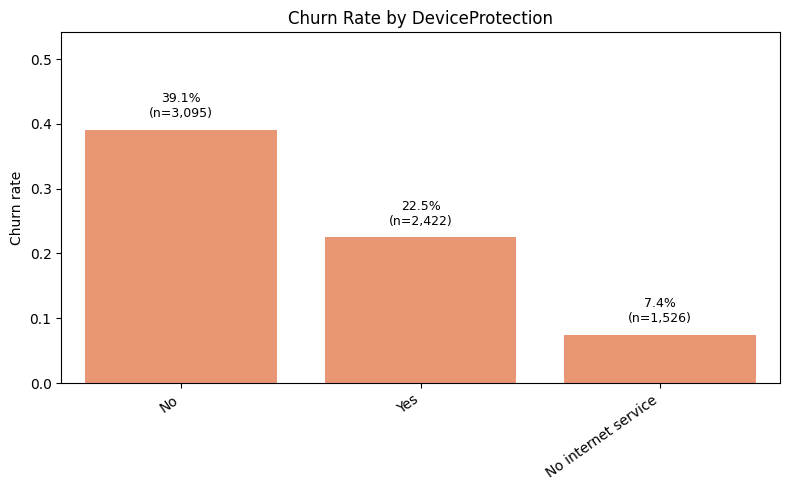

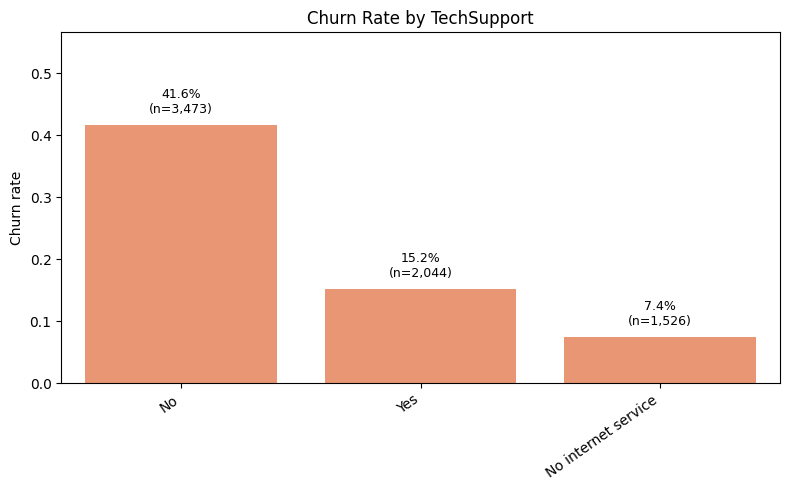

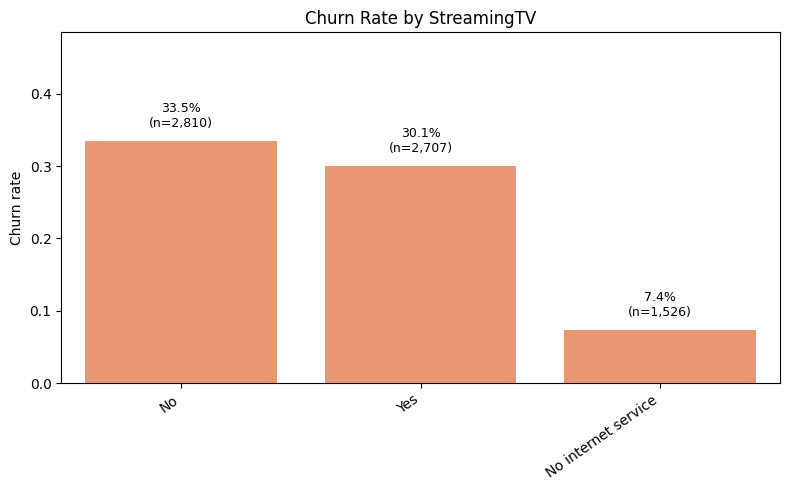

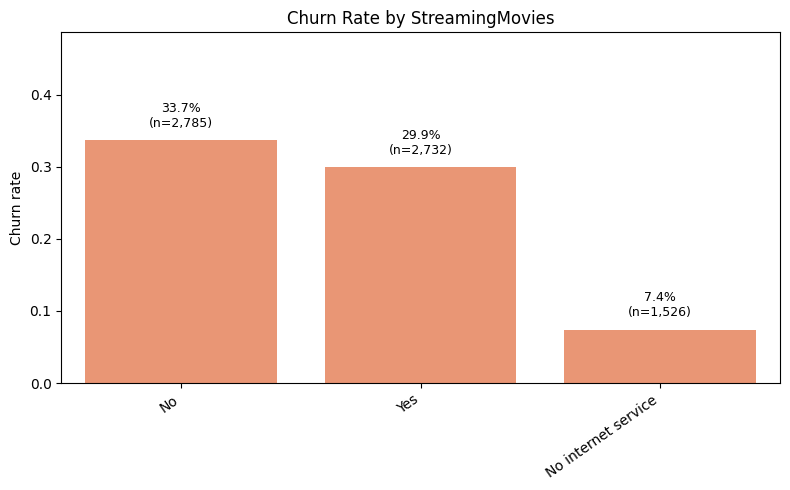

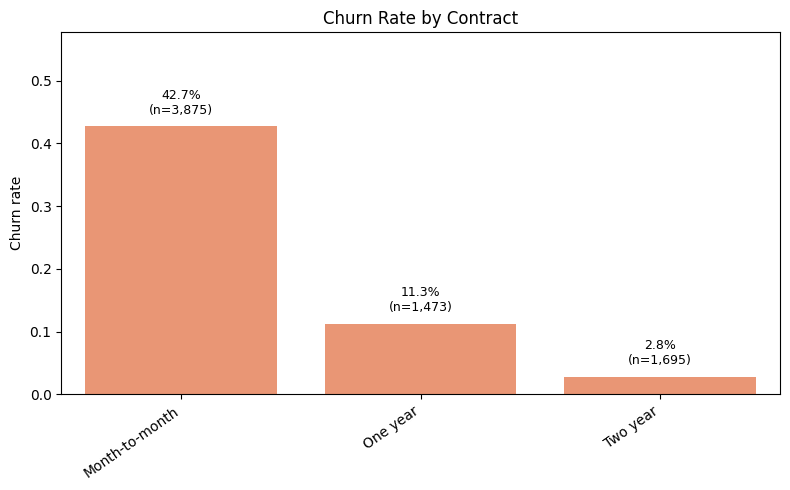

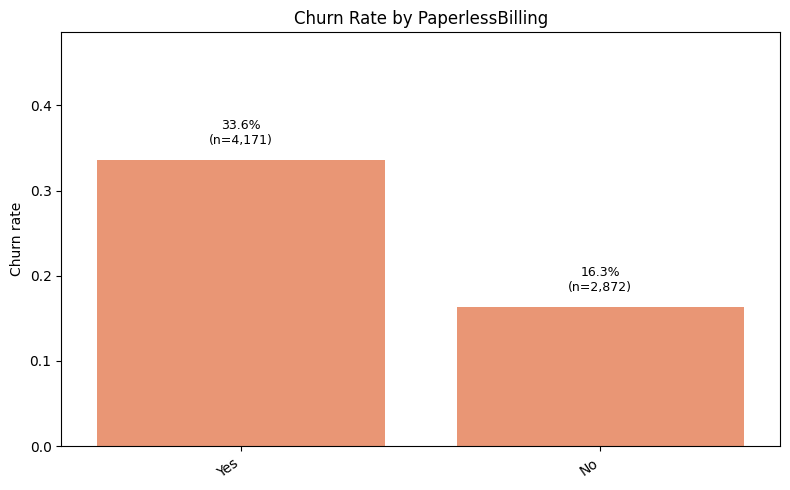

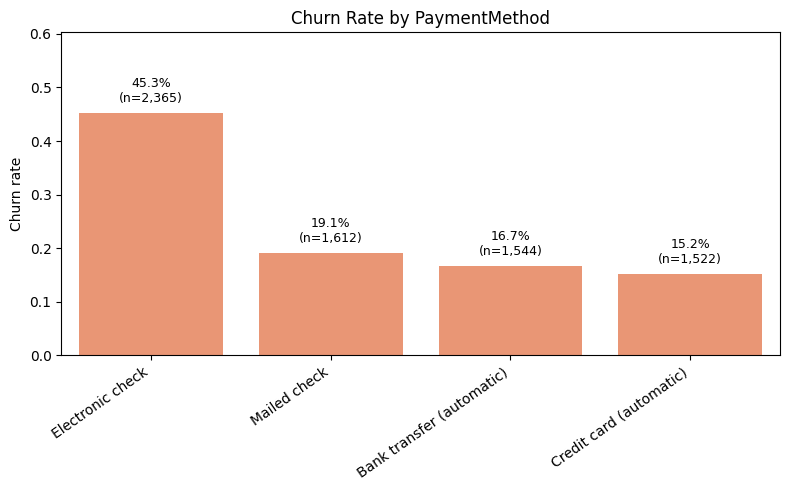

In [197]:
for feature in categorical_features:

    summary = (
        df.groupby(feature, observed=True)
        .agg(
            ChurnRate=("ChurnBinary", "mean"),
            Customers=("ChurnBinary", "size")
        )
        .sort_values("ChurnRate", ascending=False)
        .reset_index()
    )

    plt.figure(figsize=(8, 5))

    ax = sns.barplot(
        data=summary,
        x=feature,
        y="ChurnRate",
        color="#fc8d62"
    )

    for i, row in summary.iterrows():
        ax.text(
            i,
            row["ChurnRate"] + 0.015,
            f"{row['ChurnRate']:.1%}\n(n={row['Customers']:,})",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.title(f"Churn Rate by {feature}")
    plt.xlabel("")
    plt.ylabel("Churn rate")
    plt.ylim(0, min(1, summary["ChurnRate"].max() + 0.15))
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

 - Single users with no dependents tend to churn more than partnered and/or with dependents
 - Number of phone lines, gender, phone service seem to not play a role in churn rates
 - Customers with no online security, no device protection, no online backup and no TechSupport tend to churn more
 - Customers with FiberOptic internet tend to churn more
 - Having Streaming Services does not appear to affect churning rates
 - Month-to-month contract appears to make customers churn more
 - Customer with paperless billing churn at double the rate
 - Customers that pay for services using e-check tend to churn at 2-3 x higher rate than customers paying using other methods

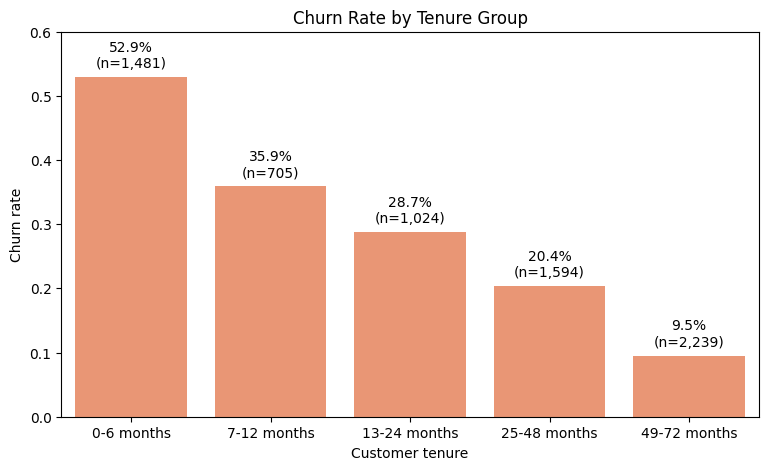

In [198]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=[
        "0-6 months",
        "7-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ]
)

tenure_summary = (
    df.groupby("TenureGroup", observed=True)
    .agg(
        ChurnRate=("ChurnBinary", "mean"),
        Customers=("ChurnBinary", "size")
    )
    .reset_index()
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=tenure_summary,
    x="TenureGroup",
    y="ChurnRate",
    color="#fc8d62"
)

for i, row in tenure_summary.iterrows():
    ax.text(
        i,
        row["ChurnRate"] + 0.015,
        f"{row['ChurnRate']:.1%}\n(n={row['Customers']:,})",
        ha="center",
        fontsize=10
    )

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Customer tenure")
plt.ylabel("Churn rate")
plt.ylim(0, 0.6)
plt.show()

Customers that are new are much more likely to churn within the first 6 months, and customers are decreasingly likely to switch as their tenure grows with only 9.5% of customers churning if they have been with the company for over 4 years.

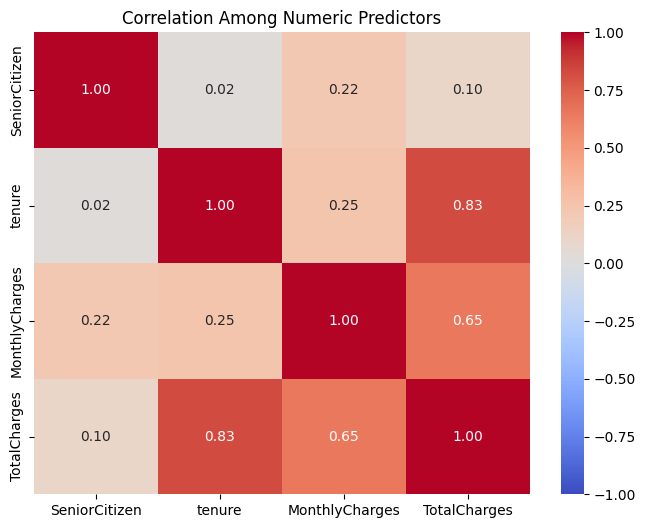

In [199]:
correlation_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    df[correlation_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Correlation Among Numeric Predictors")
plt.show()

The correlation matrix shows a strong positive correlation between tenure and
TotalCharges, approximately 0.83. There is also a moderate correlation between
MonthlyCharges and TotalCharges.

The strong relationship between tenure and TotalCharges is expected because customers who
remain with the company longer generally accumulate more total charges. This creates a
multicollinearity concern for linear and logistic regression: the models may still predict
well, but the individual coefficients for tenure and TotalCharges may be difficult to
interpret independently.

# Linear Regression: Assumptions validations

In [200]:
model_features = numeric_features + categorical_features

X_encoded = pd.get_dummies(
    df[model_features],
    drop_first=True,
    dtype=float
)

y = df["ChurnBinary"]

X_linear = add_constant(X_encoded)

linear_model = sm.OLS(
    y,
    X_linear
).fit()

print(linear_model.summary())

                            OLS Regression Results                            
Dep. Variable:            ChurnBinary   R-squared:                       0.283
Model:                            OLS   Adj. R-squared:                  0.281
Method:                 Least Squares   F-statistic:                     125.9
Date:                Sat, 05 Sep 2026   Prob (F-statistic):               0.00
Time:                        05:58:33   Log-Likelihood:                -3064.5
No. Observations:                7043   AIC:                             6175.
Df Residuals:                    7020   BIC:                             6333.
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

**Linear Regression Assumptions:**

---


- Linearity
- Homoscedasticity
- Normal residuals
- Independence



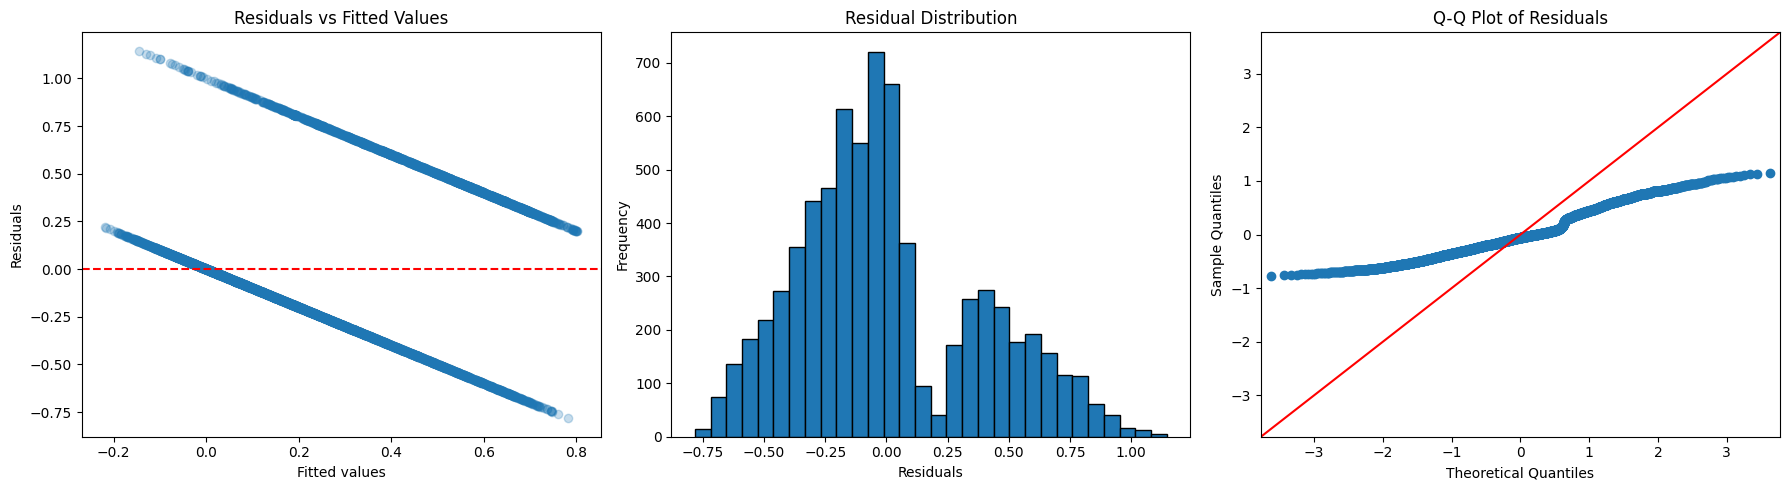

In [201]:
fitted_values = linear_model.fittedvalues
residuals = linear_model.resid

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Linearity and homoscedasticity
axes[0].scatter(
    fitted_values,
    residuals,
    alpha=0.25
)

axes[0].axhline(
    0,
    color="red",
    linestyle="--"
)

axes[0].set_title("Residuals vs Fitted Values")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")

# Residual normality
axes[1].hist(
    residuals,
    bins=30,
    edgecolor="black"
)

axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residuals")
axes[1].set_ylabel("Frequency")

# Q-Q plot
sm.qqplot(
    residuals,
    line="45",
    ax=axes[2]
)

axes[2].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

The residuals-versus-fitted plot is used to assess linearity and homoscedasticity. Here the plot does not show a random cloud. Instead, the residuals form two visible bands because the outcome is binary: each customer either stayed or
churned. This indicates that ordinary linear regression is not an ideal model for this target.

The residual histogram is not approximately normal, and the Q-Q plot shows substantial
deviation from the diagonal line.  Q-Q plot independently confirms
that the residuals are not normally distributed.

Each row represents a unique customer, and there is no repeated-customer or time-order
variable available. Independence is therefore plausible based on the dataset structure,
although it cannot be proven because the data-collection process is not documented.

In [202]:
# run statistical tests
# Breusch-Pagan test for constant residual variance
bp_results = het_breuschpagan(
    residuals,
    linear_model.model.exog
)

print("Breusch-Pagan p-value:", bp_results[1])

# Shapiro-Wilk test for residual normality
shapiro_results = shapiro(residuals)

print("Shapiro-Wilk p-value:", shapiro_results.pvalue)

Breusch-Pagan p-value: 9.853099447183534e-274
Shapiro-Wilk p-value: 1.4018601019256806e-39


/usr/local/lib/python3.13/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7043.
  res = hypotest_fun_out(*samples, **kwds)


The Breusch-Pagan test produced a p-value of approximately 0. Because this p-value is
below 0.05, we reject the assumption of constant residual variance. The residual variance changes across the fitted values.

The Shapiro-Wilk test produced a p-value of
approximately 0. Because the sample contains more than 5,000 observations, the exact p-value should be interpreted cautiously.

Overall, the linear-regression assumptions are not fully met. This is expected because
churn is a binary outcome rather than a continuous normally distributed outcome. Linear
regression is therefore useful as a descriptive baseline, but it is not the preferred
model for predicting churn probabilities. Logistic regression is more appropriate for
the binary target.

# Logistic Regression: Assumptions validations




**Binary Outcome Assumption test**: ChurnBinary contains only 0 and 1 and has no missing values.

In [203]:
# Recreate the binary churn column in df
df["ChurnBinary"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("Original target values:")
print(df["Churn"].unique())

print("\nEncoded target values:")
print(df["ChurnBinary"].unique())

print("\nTarget counts:")
print(df["ChurnBinary"].value_counts())

print("\nTarget proportions:")
print(df["ChurnBinary"].value_counts(normalize=True).round(3))

print("\nMissing target values:")
print(df["ChurnBinary"].isna().sum())

Original target values:
['No' 'Yes']

Encoded target values:
[0 1]

Target counts:
ChurnBinary
0    5174
1    1869
Name: count, dtype: int64

Target proportions:
ChurnBinary
0    0.735
1    0.265
Name: proportion, dtype: float64

Missing target values:
0


The target variable is binary. `Churn` contains the values `No` and `Yes`, which were
encoded as 0 and 1 in `ChurnBinary`. There are 5,174 customers who stayed and 1,869
customers who churned, with no missing target values.

Therefore, the binary-outcome assumption for logistic regression is satisfied. The target
is moderately imbalanced because approximately 26.5% of customers churned, so accuracy
alone should not be used to evaluate the model.

**Independence Asumption**: customer’s row should not be a repeated measurement of another customer

In [204]:
# Check whether the current dataframe has one row per observation
print("Number of rows:", len(df))
print("Number of unique row indices:", df.index.nunique())

Number of rows: 7043
Number of unique row indices: 7043


The dataset originally contained one unique `customerID` for each of the 7,043 rows.
There is no repeated-customer identifier, time-order variable, or repeated-measurement
structure in the data.

Therefore, independence is plausible based on the structure of the dataset. However,
independence cannot be proven because the original sampling and data-collection process
is not documented.

**No perfect Separation Assumption**: logistic regression can fail when one predictor category perfectly predicts the outcome.

In [205]:
separation_check = []

for feature in categorical_features:

    summary = (
        df.groupby(feature, observed=True)
        .agg(
            Customers=("ChurnBinary", "size"),
            ChurnRate=("ChurnBinary", "mean")
        )
        .reset_index()
    )

    separation_check.append({
        "Feature": feature,
        "Smallest category size": summary["Customers"].min(),
        "Largest category size": summary["Customers"].max(),
        "Minimum churn rate": summary["ChurnRate"].min(),
        "Maximum churn rate": summary["ChurnRate"].max(),
        "Possible separation": (
            (summary["ChurnRate"] == 0).any()
            or
            (summary["ChurnRate"] == 1).any()
        )
    })

separation_check = pd.DataFrame(separation_check)

display(separation_check)

,Feature,Smallest category size,Largest category size,Minimum churn rate,Maximum churn rate,Possible separation
0,gender,3488,3555,0.261603,0.269209,False
1,Partner,3402,3641,0.196649,0.329580,False
2,Dependents,2110,4933,0.154502,0.312791,False
3,PhoneService,682,6361,0.249267,0.267096,False
4,MultipleLines,682,3390,0.249267,0.286099,False
5,InternetService,1526,3096,0.074050,0.418928,False
6,OnlineSecurity,1526,3498,0.074050,0.417667,False
7,OnlineBackup,1526,3088,0.074050,0.399288,False
8,DeviceProtection,1526,3095,0.074050,0.391276,False
9,TechSupport,1526,3473,0.074050,0.416355,False


The categorical predictors were checked for categories with churn rates of exactly 0%
or 100%. No such categories were found. Therefore, there is no obvious perfect separation at the individual categorical-feature
level.

**Logistic Linearity in Log-odds Assumption**: each continuous predictor has an approximately linear relationship with the log-odds of the outcome.

,FeatureBin,MeanFeatureValue,ChurnRate,Customers,LogOdds
0,"(-0.001, 2.0]",1.263341,0.583527,862,0.337268
1,"(2.0, 6.0]",4.247173,0.453958,619,-0.184691
2,"(6.0, 12.0]",9.397163,0.358865,705,-0.580293
3,"(12.0, 20.0]",16.297688,0.309249,692,-0.803635
4,"(20.0, 29.0]",24.849493,0.228654,691,-1.215926
5,"(29.0, 40.0]",34.834031,0.218968,717,-1.271691
6,"(40.0, 50.0]",45.536810,0.176380,652,-1.541066
7,"(50.0, 60.0]",55.445559,0.136103,698,-1.848040
8,"(60.0, 69.0]",65.300265,0.092593,756,-2.282382
9,"(69.0, 72.0]",71.373272,0.035330,651,-3.307046


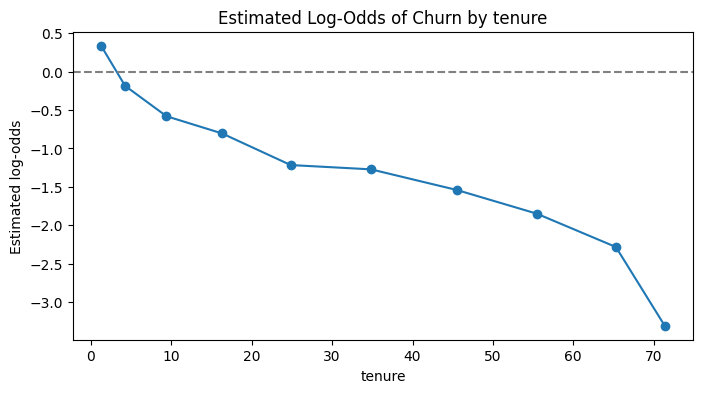

,FeatureBin,MeanFeatureValue,ChurnRate,Customers,LogOdds
0,"(18.249, 20.05]",19.629637,0.085077,717,-2.375287
1,"(20.05, 25.05]",21.813229,0.098151,703,-2.217942
2,"(25.05, 45.85]",35.710144,0.254676,695,-1.073826
3,"(45.85, 58.83]",52.551282,0.245014,702,-1.125383
4,"(58.83, 70.35]",65.357454,0.215190,711,-1.293921
5,"(70.35, 79.1]",74.673286,0.381429,700,-0.483489
6,"(79.1, 85.5]",82.162979,0.378723,705,-0.494970
7,"(85.5, 94.25]",89.865028,0.343305,702,-0.648601
8,"(94.25, 102.6]",98.048224,0.409091,704,-0.367725
9,"(102.6, 118.75]",108.268963,0.247159,704,-1.113822


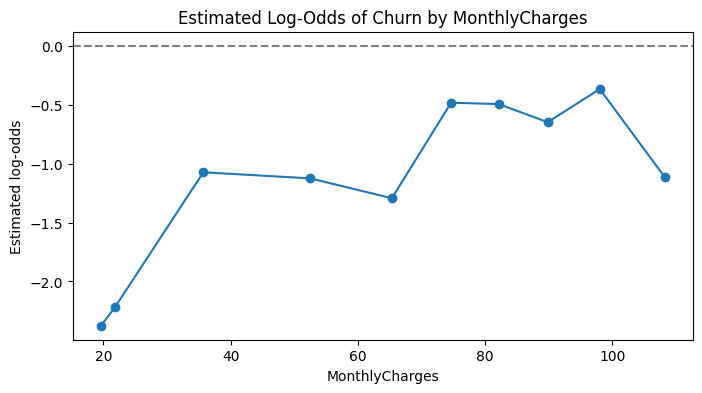

,FeatureBin,MeanFeatureValue,ChurnRate,Customers,LogOdds
0,"(-0.001, 83.47]",47.880993,0.517730,705,0.070952
1,"(83.47, 265.32]",166.060227,0.397727,704,-0.414944
2,"(265.32, 548.4]",398.534517,0.306818,704,-0.815037
3,"(548.4, 939.78]",741.142045,0.271307,704,-0.988002
4,"(939.78, 1394.55]",1167.725248,0.222695,705,-1.250029
5,"(1394.55, 2043.71]",1688.916619,0.194602,704,-1.420378
6,"(2043.71, 3132.75]",2570.900000,0.280851,705,-0.940244
7,"(3132.75, 4471.44]",3787.014225,0.179232,703,-1.521560
8,"(4471.44, 5973.69]",5208.207528,0.157670,704,-1.675664
9,"(5973.69, 8684.8]",7020.704539,0.124823,705,-1.947532


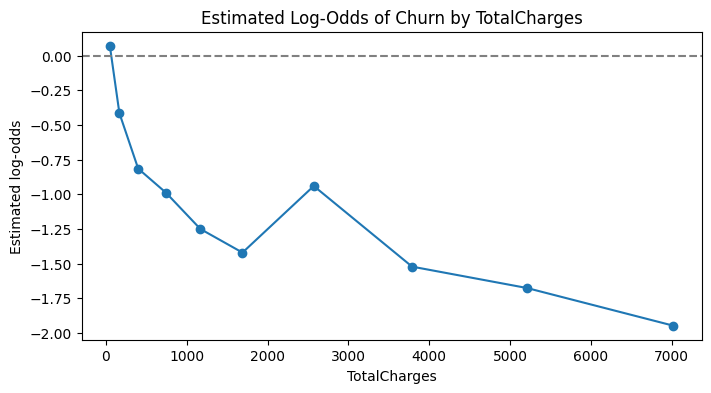

In [206]:
# Make sure the variables used for this diagnostic are numeric
log_odds_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

for feature in log_odds_features:

    # Explicitly convert the feature to numeric
    feature_values = pd.to_numeric(
        df[feature],
        errors="coerce"
    )

    # Keep only valid values for this diagnostic
    diagnostic_data = pd.DataFrame({
        "FeatureValue": feature_values,
        "ChurnBinary": df["ChurnBinary"]
    }).dropna()

    # Create ten equally populated bins
    diagnostic_data["FeatureBin"] = pd.qcut(
        diagnostic_data["FeatureValue"],
        q=10,
        duplicates="drop"
    )

    # Calculate the observed churn rate in each bin
    bin_summary = (
        diagnostic_data
        .groupby("FeatureBin", observed=True)
        .agg(
            MeanFeatureValue=("FeatureValue", "mean"),
            ChurnRate=("ChurnBinary", "mean"),
            Customers=("ChurnBinary", "size")
        )
        .reset_index()
    )

    # Convert churn rate to estimated log-odds
    probability = np.clip(
        bin_summary["ChurnRate"],
        0.001,
        0.999
    )

    bin_summary["LogOdds"] = np.log(
        probability / (1 - probability)
    )

    display(bin_summary)

    # Plot estimated log-odds against the feature
    plt.figure(figsize=(8, 4))

    plt.plot(
        bin_summary["MeanFeatureValue"],
        bin_summary["LogOdds"],
        marker="o"
    )

    plt.axhline(
        0,
        color="gray",
        linestyle="--"
    )

    plt.title(
        f"Estimated Log-Odds of Churn by {feature}"
    )

    plt.xlabel(feature)
    plt.ylabel("Estimated log-odds")
    plt.show()

The plots show the estimated log-odds of churn across bins of each continuous predictor.
The dashed horizontal line at zero represents equal odds of churn and non-churn. Most
estimated log-odds are below zero, which is consistent with the overall churn rate being
less than 50%. The vertical position should therefore be interpreted as relative odds,
not as a direct probability.

The relationship between tenure and the log-odds of churn is strongly negative. Customers
with very short tenure have the highest estimated log-odds of churn, while customers with
longer tenure have progressively lower estimated log-odds.

The decrease is steep during the earliest tenure periods and becomes more gradual later.
This curved pattern suggests that tenure does not have a simple linear relationship with
the log-odds of churn. A single linear tenure coefficient may therefore be too restrictive.

The relationship between TotalCharges and the log-odds of churn is generally negative,
but it is not a straight line. The log-odds decrease at lower and higher charge levels,
with a visible increase in the middle range.

This non-monotonic pattern suggests that a single linear TotalCharges term may not fully
represent the relationship. However, TotalCharges is also strongly correlated with tenure,
so its apparent pattern should be interpreted cautiously.


The relationship between MonthlyCharges and the log-odds of churn is irregular and
non-monotonic. The estimated log-odds increase across some charge ranges, decrease across
others, and then increase again before falling at the highest observed value.

This pattern suggests that a simple linear MonthlyCharges term may not adequately capture
the relationship. The irregularity may reflect nonlinear behavior, interactions with
contract or service type, or variation within the bins.

The binned log-odds plots provide evidence that the linearity-in-the-log-odds assumption
may be violated for at least some numeric predictors. In particular, tenure shows a clear
curved relationship, while TotalCharges and MonthlyCharges show non-monotonic patterns.

Therefore, standard logistic regression remains useful as an interpretable baseline, but
a model with nonlinear terms should also be considered. A GAM is appropriate for the next
stage because it can represent smooth, nonlinear feature effects while preserving
interpretability.

These plots show associations in the observed data and should not be interpreted as
evidence that changing tenure, charges, or any other feature would cause churn.

**Limited Multicollinearity Assumption**: highly correlated predictors can make logistic-regression coefficients unstable and difficult to interpret.

SeniorCitizen       int64
tenure              int64
MonthlyCharges    float64
TotalCharges      float64
dtype: object


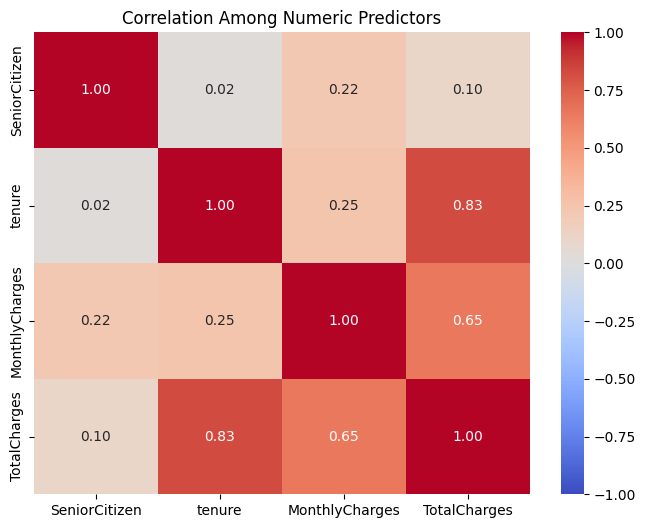

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.103006
tenure,0.016567,1.000000,0.247900,0.826178
MonthlyCharges,0.220173,0.247900,1.000000,0.651174
TotalCharges,0.103006,0.826178,0.651174,1.000000


In [207]:
# Convert all numeric columns again
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

for feature in numeric_features:
    df[feature] = pd.to_numeric(
        df[feature].astype(str).str.strip(),
        errors="coerce"
    )

# Replace missing TotalCharges values with zero
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Check the data types
print(df[numeric_features].dtypes)

# Calculate the correlation matrix
correlation_matrix = df[numeric_features].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Correlation Among Numeric Predictors")
plt.show()

display(correlation_matrix)

The correlation matrix shows a strong positive correlation between tenure and TotalCharges,
approximately 0.83. This is expected because customers who remain with the company longer
generally accumulate more total charges.


**Sufficient Sample Size Assumption**: logistic regression needs enough observations, with a common rule of thumb of approximately 10–20 outcome events per predictor.

In [208]:
# Create the encoded predictor matrix
model_features = numeric_features + categorical_features

X_encoded = pd.get_dummies(
    df[model_features],
    drop_first=True,
    dtype=float
)

# Count churn events and non-events
number_of_events = df["ChurnBinary"].sum()
number_of_non_events = (df["ChurnBinary"] == 0).sum()
number_of_predictors = X_encoded.shape[1]

events_per_predictor = (
    number_of_events / number_of_predictors
)

print("Number of churn events:", number_of_events)
print("Number of non-churn events:", number_of_non_events)
print("Number of encoded predictors:", number_of_predictors)
print("Events per encoded predictor:", round(events_per_predictor, 2))

Number of churn events: 1869
Number of non-churn events: 5174
Number of encoded predictors: 30
Events per encoded predictor: 62.3


The dataset contains 1,869 churn events and 5,174 non-churn observations. After one-hot
encoding the categorical variables, the model contains approximately 30 predictors. This
corresponds to approximately 62 churn events per encoded predictor.

This is above the common rule of thumb of 10–20 events per predictor. Therefore, the
sample-size assumption appears reasonably satisfied for the logistic regression model.

# GAM: Assumptions validations

**Nonlinear Feature Effects Assumption**: A GAM is useful when the relationship between a feature and the outcome is not adequately represented by a straight line.

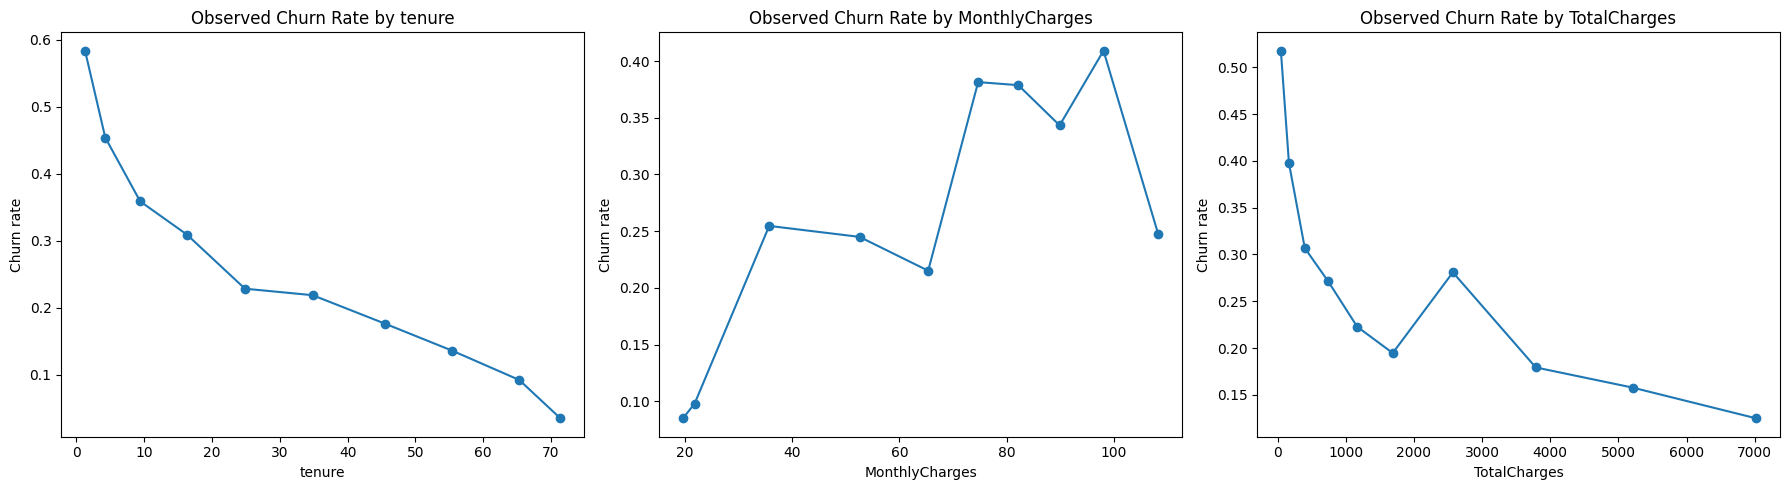

In [209]:

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for ax, feature in zip(axes, gam_smooth_features):

    diagnostic_data = df[
        [feature, "ChurnBinary"]
    ].copy()

    diagnostic_data[feature] = pd.to_numeric(
        diagnostic_data[feature],
        errors="coerce"
    )

    diagnostic_data = diagnostic_data.dropna()

    diagnostic_data["FeatureBin"] = pd.qcut(
        diagnostic_data[feature],
        q=10,
        duplicates="drop"
    )

    bin_summary = (
        diagnostic_data
        .groupby("FeatureBin", observed=True)
        .agg(
            MeanFeatureValue=(feature, "mean"),
            ChurnRate=("ChurnBinary", "mean"),
            Customers=("ChurnBinary", "size")
        )
        .reset_index()
    )

    ax.plot(
        bin_summary["MeanFeatureValue"],
        bin_summary["ChurnRate"],
        marker="o"
    )

    ax.set_title(f"Observed Churn Rate by {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Churn rate")

plt.tight_layout()
plt.show()

The plots show that churn rates vary nonlinearly across the numeric features.

Churn decreases sharply as tenure increases, especially during the first several months.
This suggests that a single straight-line effect may not fully describe the relationship.

MonthlyCharges shows a non-monotonic pattern. Churn rates increase substantially for
higher monthly charges, but the relationship is not perfectly straight.

TotalCharges generally shows decreasing churn as charges increase, with a noticeable
increase in the middle range. This pattern should be interpreted cautiously because
TotalCharges is strongly related to tenure.

Overall, the observed curvature supports testing a GAM with smooth feature effects.

**Additive Structure Assumption**: A **GAM** is linear in its _additive_ structure — the feature contributions are summed without interaction terms.

The initial GAM will use an additive structure in which the individual feature
contributions are summed together. Each numeric feature will receive its own smooth
function, while categorical predictors will be represented by separate encoded terms.

No interaction terms will be included initially. Therefore, the model assumes that the
effect of one predictor does not depend on the value of another predictor.

This assumption cannot be fully verified from the univariate plots alone. However, the
additive GAM provides an interpretable first model. If the final model shows systematic
errors for particular combinations of features, interactions could be investigated in a
later analysis.

# Linear Regression Model

In [210]:
# Make sure the target exists
df["ChurnBinary"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Use all individual predictors
model_features = numeric_features + categorical_features

# One-hot encode categorical predictors
X = pd.get_dummies(
    df[model_features],
    drop_first=True,
    dtype=float
)

y = df["ChurnBinary"].astype(float)

# Split before fitting the model
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])
print("Number of encoded predictors:", X_train.shape[1])

Training observations: 5634
Testing observations: 1409
Number of encoded predictors: 30


In [211]:
# Create and fit the linear regression model
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

# Generate predictions on the unseen test set
linear_predictions = linear_model.predict(X_test)

# Calculate performance metrics
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_mse = mean_squared_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(linear_mse)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression Performance")
print("-----------------------------")
print(f"MAE:  {linear_mae:.4f}")
print(f"RMSE: {linear_rmse:.4f}")
print(f"R²:   {linear_r2:.4f}")

print("\nPrediction range:")
print(f"Minimum prediction: {linear_predictions.min():.4f}")
print(f"Maximum prediction: {linear_predictions.max():.4f}")

Linear Regression Performance
-----------------------------
MAE:  0.3004
RMSE: 0.3794
R²:   0.2616

Prediction range:
Minimum prediction: -0.2255
Maximum prediction: 0.8355


In [212]:
# coefficient interpretation

linear_coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": linear_model.coef_
})

linear_coefficients["AbsoluteCoefficient"] = (
    linear_coefficients["Coefficient"].abs()
)

linear_coefficients = linear_coefficients.sort_values(
    "AbsoluteCoefficient",
    ascending=False
)

display(linear_coefficients.head(15))

,Feature,Coefficient,AbsoluteCoefficient
10,InternetService_Fiber optic,0.371723,0.371723
23,StreamingMovies_Yes,0.130006,0.130006
21,StreamingTV_Yes,0.129720,0.129720
24,Contract_One year,-0.109559,0.109559
9,MultipleLines_Yes,0.093342,0.093342
28,PaymentMethod_Electronic check,0.077296,0.077296
25,Contract_Two year,-0.076088,0.076088
8,MultipleLines_No phone service,-0.062033,0.062033
7,PhoneService_Yes,0.062033,0.062033
26,PaperlessBilling_Yes,0.048438,0.048438


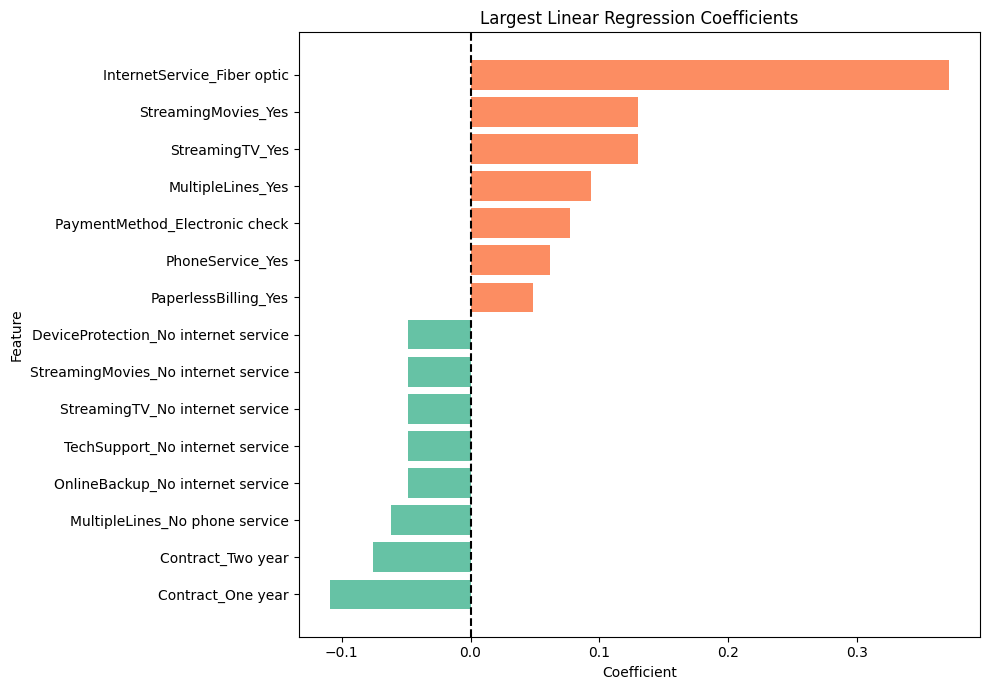

In [213]:
top_coefficients = (
    linear_coefficients
    .head(15)
    .sort_values("Coefficient")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"],
    color=[
        "#fc8d62" if value > 0 else "#66c2a5"
        for value in top_coefficients["Coefficient"]
    ]
)

plt.axvline(
    0,
    color="black",
    linestyle="--"
)

plt.title("Largest Linear Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

The largest positive coefficient is associated with Fiber optic internet service,
indicating a higher predicted churn score compared with the reference internet-service
category, holding other predictors constant.

Electronic check payment, paperless billing, streaming services, and having multiple lines
also have positive coefficients. These categories are associated with higher predicted
churn scores relative to their reference categories.

One-year and two-year contracts have the largest negative coefficients, indicating lower
predicted churn scores compared with the month-to-month contract reference category.
Several “No internet service” categories also have negative coefficients.

These coefficients represent conditional associations, not causal effects. Because the
predictors were not standardized, coefficient magnitudes should not be interpreted as
directly comparable feature importance scores. The linear model also predicts a continuous
churn score rather than a valid probability, as shown by its negative predictions.

# Logistic Regression Model


In [214]:
from sklearn.linear_model import LogisticRegression

# Create the logistic regression model
logistic_model = LogisticRegression(
    max_iter=5000,
    solver="liblinear",
    random_state=42
)

# Fit using the training data
logistic_model.fit(
    X_train,
    y_train
)

# Predict probabilities of churn
logistic_probabilities = logistic_model.predict_proba(
    X_test
)[:, 1]

# Predict class labels using the default 0.5 threshold
logistic_predictions = logistic_model.predict(
    X_test
)

print("Minimum predicted probability:", logistic_probabilities.min())
print("Maximum predicted probability:", logistic_probabilities.max())

Minimum predicted probability: 0.002041007816739457
Maximum predicted probability: 0.8659001094322525


In [215]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

logistic_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions
)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"ROC-AUC:  {logistic_auc:.4f}")
print(f"Accuracy: {logistic_accuracy:.4f}")
print(f"Precision:{logistic_precision:.4f}")
print(f"Recall:   {logistic_recall:.4f}")
print(f"F1 score: {logistic_f1:.4f}")

Logistic Regression Performance
--------------------------------
ROC-AUC:  0.8423
Accuracy: 0.8027
Precision:0.6529
Recall:   0.5481
F1 score: 0.5959


ROC-AUC measures how well the model separates customers who churn from customers who
stay across different probability thresholds. Precision measures how often predicted
churners actually churn, while recall measures how many actual churners the model
identifies. The F1 score balances precision and recall.

Because the dataset is moderately imbalanced, ROC-AUC, recall, precision, and F1 are
more informative than accuracy alone.

The logistic regression model has a ROC-AUC of 0.8423, indicating good ability to
distinguish between customers who churn and customers who stay.

Using the default 0.5 threshold, the model correctly classified 80.3% of customers.
Among predicted churners, approximately 65.3% actually churned. The model identified
approximately 54.8% of all customers who churned.

The confusion matrix shows 205 correctly identified churners and 169 churners that the
model missed. It also incorrectly flagged 109 customers who stayed as churners.

The model ranks customers reasonably well, but the default threshold misses a substantial
number of actual churners. If identifying potential churners is especially important, the
company could consider lowering the classification threshold.

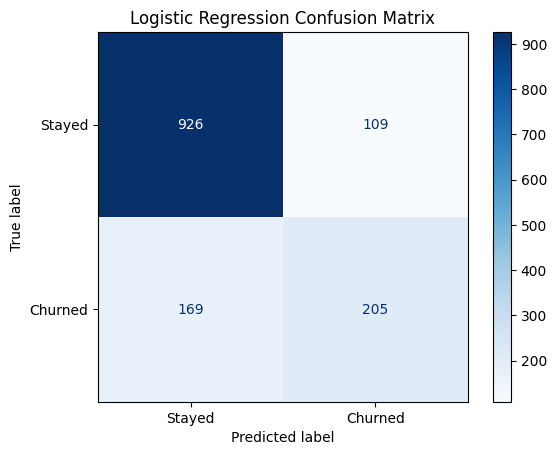

In [216]:
cm = confusion_matrix(
    y_test,
    logistic_predictions
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
).plot(
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [217]:
logistic_coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": logistic_model.coef_[0]
})

logistic_coefficients["OddsRatio"] = np.exp(
    logistic_coefficients["Coefficient"]
)

logistic_coefficients["AbsoluteCoefficient"] = (
    logistic_coefficients["Coefficient"].abs()
)

logistic_coefficients = logistic_coefficients.sort_values(
    "AbsoluteCoefficient",
    ascending=False
)

display(
    logistic_coefficients.head(20)
)

,Feature,Coefficient,OddsRatio,AbsoluteCoefficient
25,Contract_Two year,-0.845546,0.429323,0.845546
10,InternetService_Fiber optic,0.672536,1.959199,0.672536
13,OnlineSecurity_Yes,-0.537393,0.584270,0.537393
24,Contract_One year,-0.531323,0.587827,0.531323
19,TechSupport_Yes,-0.496778,0.608488,0.496778
7,PhoneService_Yes,-0.493673,0.610380,0.493673
26,PaperlessBilling_Yes,0.402601,1.495709,0.402601
9,MultipleLines_Yes,0.274141,1.315400,0.274141
28,PaymentMethod_Electronic check,0.255528,1.291143,0.255528
8,MultipleLines_No phone service,0.237324,1.267852,0.237324


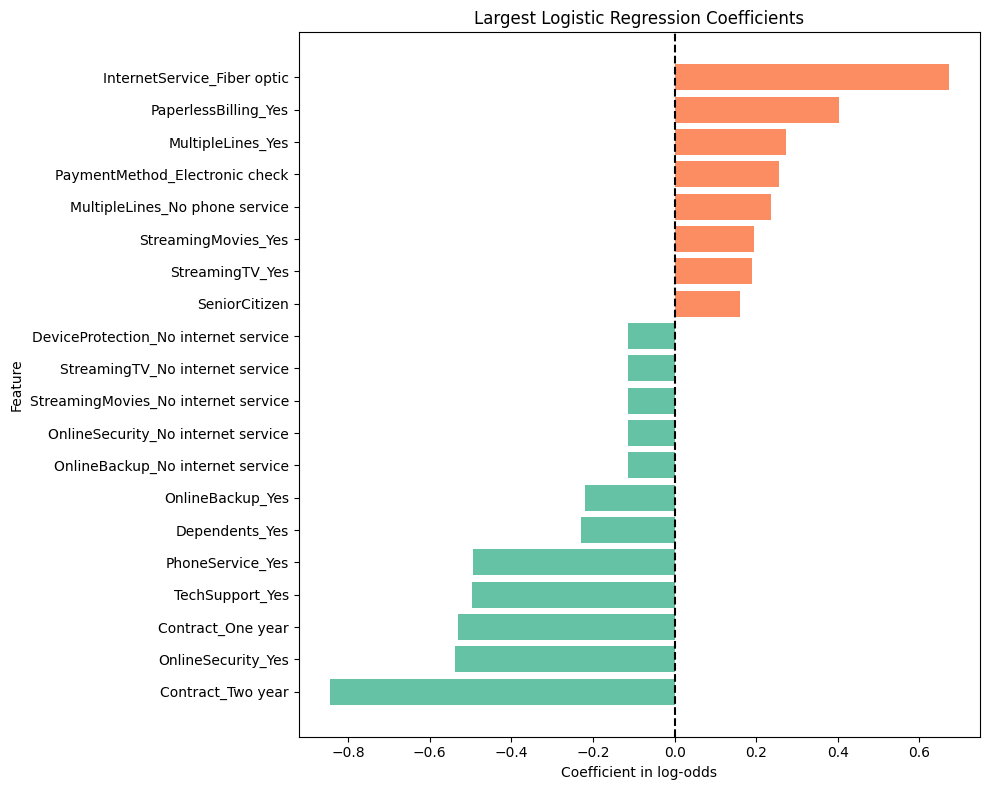

In [218]:
top_logistic_coefficients = (
    logistic_coefficients
    .head(20)
    .sort_values("Coefficient")
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_logistic_coefficients["Feature"],
    top_logistic_coefficients["Coefficient"],
    color=[
        "#fc8d62" if value > 0 else "#66c2a5"
        for value in top_logistic_coefficients["Coefficient"]
    ]
)

plt.axvline(
    0,
    color="black",
    linestyle="--"
)

plt.title("Largest Logistic Regression Coefficients")
plt.xlabel("Coefficient in log-odds")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Compared with month-to-month contracts, customers with two-year contracts have estimated
churn odds multiplied by 0.43, or approximately 57% lower odds. Customers with one-year
contracts have approximately 41% lower estimated odds of churn.

Compared with the reference internet-service category, Fiber optic service is associated
with approximately 1.96 times higher estimated churn odds.

Customers with online security and technical support have lower estimated churn odds than
the corresponding reference categories. Their odds ratios are approximately 0.58 and
0.61, respectively.

Paperless billing is associated with approximately 1.50 times higher estimated churn odds.
Electronic-check payment is associated with approximately 1.29 times higher estimated
churn odds than the reference payment method.

SeniorCitizen has an odds ratio of approximately 1.17, indicating modestly higher
estimated churn odds for senior citizens, holding the other predictors constant.

These are conditional associations, not causal effects. Categorical coefficients compare
each displayed category with an omitted reference category. The coefficient magnitudes
should not be treated as direct feature-importance rankings because the predictors use
different units and tenure is correlated with TotalCharges.

# GAM Model

In [219]:
!pip install pygam --quiet

In [220]:
from pygam import LogisticGAM, s, f

In [221]:
# Use the same encoded features for a fair comparison
model_features = numeric_features + categorical_features

X_gam = pd.get_dummies(
    df[model_features],
    drop_first=True,
    dtype=float
)

y_gam = df["ChurnBinary"].astype(int)

# Use the same train/test rows as the other models
X_gam_train, X_gam_test, y_gam_train, y_gam_test = train_test_split(
    X_gam,
    y_gam,
    test_size=0.20,
    random_state=42,
    stratify=y_gam
)

# Find the columns corresponding to the original continuous predictors
smooth_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

smooth_indices = [
    X_gam.columns.get_loc(feature)
    for feature in smooth_features
]

categorical_indices = [
    i for i in range(X_gam.shape[1])
    if i not in smooth_indices
]

# Build an additive GAM:
# smooth terms for continuous variables,
# factor terms for one-hot encoded categorical variables
terms = s(smooth_indices[0])

for index in smooth_indices[1:]:
    terms = terms + s(index)

for index in categorical_indices:
    terms = terms + f(index)

gam_model = LogisticGAM(terms)

# Select smoothing parameters using cross-validation
gam_model.gridsearch(
    X_gam_train.values,
    y_gam_train.values
)

100% (11 of 11) |########################| Elapsed Time: 0:00:19 Time:  0:00:19


LogisticGAM(callbacks=[Deviance(), Diffs(), Accuracy()], 
   fit_intercept=True, max_iter=100, 
   terms=s(1) + s(2) + s(3) + f(0) + f(4) + f(5) + f(6) + f(7) + f(8) + f(9) + f(10) + f(11) + f(12) + f(13) + f(14) + f(15) + f(16) + f(17) + f(18) + f(19) + f(20) + f(21) + f(22) + f(23) + f(24) + f(25) + f(26) + f(27) + f(28) + f(29) + intercept,
   tol=0.0001, verbose=False)

In [222]:
# Generate GAM probability predictions
gam_probabilities = gam_model.predict_proba(
    X_gam_test.values
)

# Convert probabilities to class predictions
gam_predictions = gam_model.predict(
    X_gam_test.values
)

# Calculate performance metrics
gam_auc = roc_auc_score(
    y_gam_test,
    gam_probabilities
)

gam_accuracy = accuracy_score(
    y_gam_test,
    gam_predictions
)

gam_precision = precision_score(
    y_gam_test,
    gam_predictions
)

gam_recall = recall_score(
    y_gam_test,
    gam_predictions
)

gam_f1 = f1_score(
    y_gam_test,
    gam_predictions
)

print("GAM Performance")
print("----------------")
print(f"ROC-AUC:  {gam_auc:.4f}")
print(f"Accuracy: {gam_accuracy:.4f}")
print(f"Precision:{gam_precision:.4f}")
print(f"Recall:   {gam_recall:.4f}")
print(f"F1 score: {gam_f1:.4f}")

GAM Performance
----------------
ROC-AUC:  0.8476
Accuracy: 0.8062
Precision:0.6667
Recall:   0.5401
F1 score: 0.5968


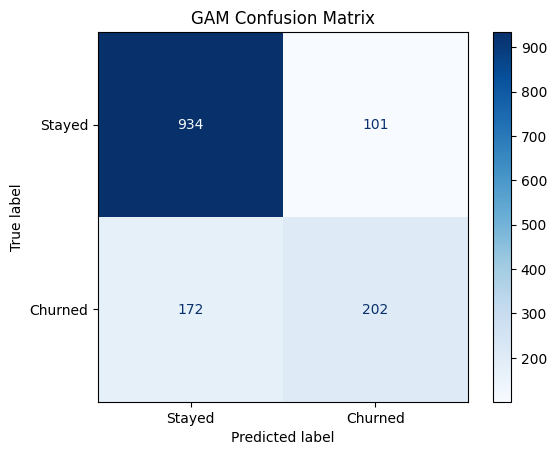

In [223]:
gam_cm = confusion_matrix(
    y_gam_test,
    gam_predictions
)

ConfusionMatrixDisplay(
    confusion_matrix=gam_cm,
    display_labels=["Stayed", "Churned"]
).plot(
    cmap="Blues"
)

plt.title("GAM Confusion Matrix")
plt.show()

The GAM achieved a ROC-AUC of 0.8476, slightly higher than the logistic regression
ROC-AUC of 0.8423. This suggests that the GAM separates churned and non-churned
customers slightly better.

The GAM also produced slightly higher accuracy and precision. However, its recall was
slightly lower, identifying 54.0% of churners compared with 54.8% for logistic regression.
The F1 scores were nearly identical.

The confusion matrix shows that the GAM correctly identified 202 churners and missed 172.
It incorrectly classified 101 customers who stayed as churners.

Overall, the GAM provides a small performance improvement over logistic regression, but
the improvement is modest. Its main advantage is the ability to represent nonlinear
relationships while remaining interpretable through feature-effect plots.

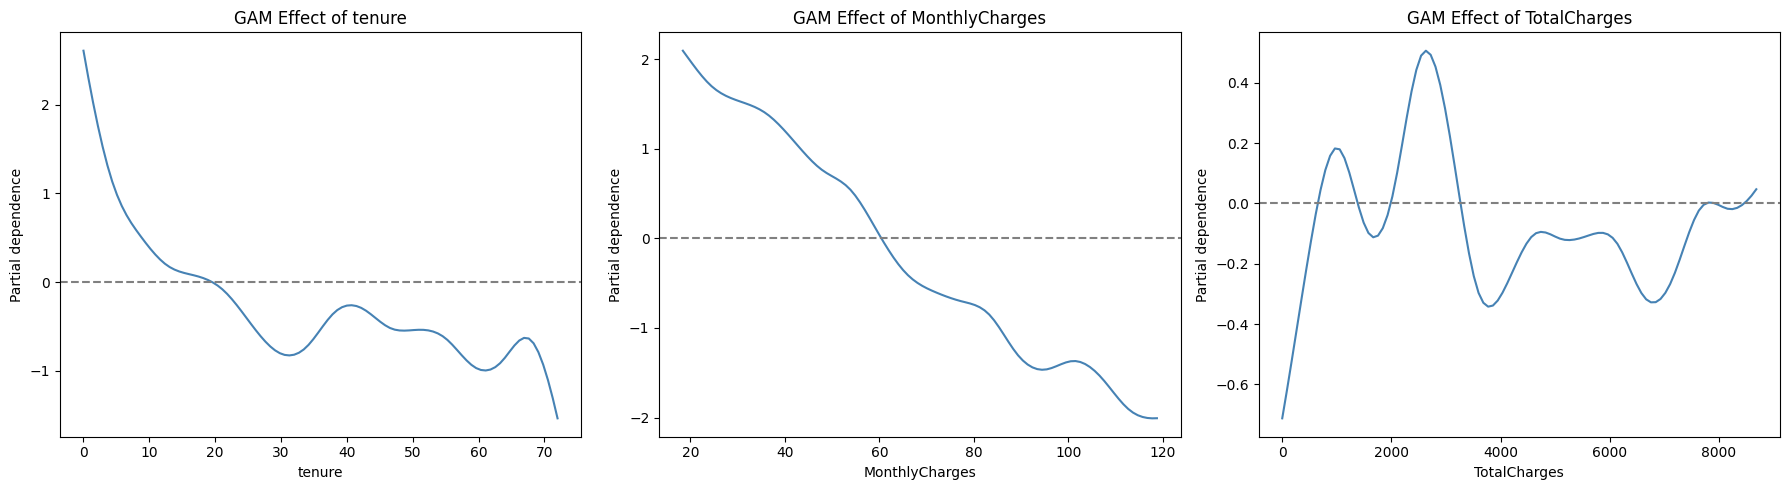

In [224]:
# Plot the smooth terms for the continuous predictors
fig, axes = plt.subplots(
    1,
    len(smooth_features),
    figsize=(18, 5)
)

for ax, feature, feature_index in zip(
    axes,
    smooth_features,
    smooth_indices
):

    # Find the GAM term associated with this feature
    term_index = None

    for i, term in enumerate(gam_model.terms):
        if not term.isintercept and term.feature == feature_index:
            term_index = i
            break

    # Create values across the feature's observed range
    XX = gam_model.generate_X_grid(
        term=term_index
    )

    # Calculate the partial dependence
    partial_effect = gam_model.partial_dependence(
        term=term_index,
        X=XX
    )

    ax.plot(
        XX[:, feature_index],
        partial_effect,
        color="steelblue"
    )

    ax.axhline(
        0,
        color="gray",
        linestyle="--"
    )

    ax.set_title(f"GAM Effect of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Partial dependence")

plt.tight_layout()
plt.show()

The GAM partial-dependence plots show the estimated contribution of each continuous
feature while averaging over the other predictors.

The GAM estimates each feature’s contribution while averaging over the other predictors.
The vertical axis represents relative contribution to the model prediction, not a direct
churn probability. The dashed line at zero represents the average-centered contribution.

The tenure effect is strongly positive for very new customers and generally decreases as
tenure increases. This indicates that newer customers contribute more strongly to predicted
churn risk, while longer-tenure customers contribute less. The relationship is nonlinear,
with the largest change occurring during the early months.

The MonthlyCharges effect generally decreases as monthly charges increase, but the curve
contains bends. This suggests that the effect is not adequately represented by a single
straight-line term.

The TotalCharges effect is highly irregular, with several changes in direction. This may
reflect a complex nonlinear relationship, but it should be interpreted cautiously because
TotalCharges is strongly correlated with tenure. Some of the fluctuations may also reflect
limited information or instability in parts of the feature range.

Overall, the GAM captures nonlinear patterns that a simple logistic-regression coefficient
would not show. The curves represent model associations, not causal effects, and the
extreme ends of the curves should be interpreted cautiously.

# Model Comparison


In [225]:
# Convert linear-regression scores to class predictions
linear_class_predictions = (
    linear_predictions >= 0.5
).astype(int)

# Build one comparison table
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Logistic Regression",
        "GAM"
    ],

    "R2": [
        linear_r2,
        np.nan,
        np.nan
    ],

    "RMSE": [
        linear_rmse,
        np.nan,
        np.nan
    ],

    "MAE": [
        linear_mae,
        np.nan,
        np.nan
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, linear_predictions),
        logistic_auc,
        gam_auc
    ],

    "Accuracy": [
        accuracy_score(y_test, linear_class_predictions),
        logistic_accuracy,
        gam_accuracy
    ],

    "Precision": [
        precision_score(
            y_test,
            linear_class_predictions,
            zero_division=0
        ),
        logistic_precision,
        gam_precision
    ],

    "Recall": [
        recall_score(
            y_test,
            linear_class_predictions,
            zero_division=0
        ),
        logistic_recall,
        gam_recall
    ],

    "F1": [
        f1_score(
            y_test,
            linear_class_predictions,
            zero_division=0
        ),
        logistic_f1,
        gam_f1
    ]
})

display(
    model_comparison.round(4)
)

,Model,R2,RMSE,MAE,ROC-AUC,Accuracy,Precision,Recall,F1
0,Linear Regression,0.2616,0.3794,0.3004,0.8297,0.7963,0.6426,0.5241,0.5773
1,Logistic Regression,NaN,NaN,NaN,0.8423,0.8027,0.6529,0.5481,0.5959
2,GAM,NaN,NaN,NaN,0.8476,0.8062,0.6667,0.5401,0.5968


Linear regression is the easiest model to interpret, but it is not ideal for a binary
target and produced invalid negative churn predictions.

Logistic regression is appropriate for predicting binary churn probabilities. It achieved
a ROC-AUC of 0.8423 and has coefficients that can be interpreted using odds ratios.

The GAM achieved the highest ROC-AUC at 0.8476 and captured nonlinear effects, especially
the relationship between tenure and churn. However, its improvement over logistic
regression was modest, and its smooth curves are more complex to interpret.

Overall, logistic regression and GAM are preferable to linear regression for this churn
problem.

# Recommendation

**Recommended model:** Logistic regression as the primary operational model, with the GAM as a
supporting analysis tool.

**Why this model:** Logistic regression provides valid churn probabilities, strong
performance, and straightforward coefficient interpretation through odds ratios. The GAM
is useful for examining nonlinear patterns and validating whether a simple linear
log-odds assumption is too restrictive.

**What the company can responsibly conclude:** Certain customer groups and service
characteristics are associated with different predicted churn risks. The model can help
prioritize customers for retention outreach.

**What the company should not conclude yet:** The model does not prove that any feature causes
churn, and a high predicted risk does not guarantee that a customer will leave.

**One next analysis we would run:** Evaluate different probability thresholds and compare the
cost of missed churners with the cost of unnecessary retention outreach.